# Notebook 02: Feature Engineering and Baseline Modelling

This notebook builds the modelling feature set from the cleaned combined dataset and develops the offline phishing-domain risk scoring models. It prepares the train, validation, and test feature matrices, evaluates unsupervised anomaly models, supervised classifiers, and hybrid candidates that include anomaly-score features, selects the best-performing XGBoost model, and exports the modelling artefacts required for later evaluation and live scoring notebooks.

## 1. Configuration

Shared paths, library imports, and output locations for saved modelling artefacts are defined before feature schema construction begins.

In [1]:
from __future__ import annotations
import json
import math
import os
from collections import Counter
from pathlib import Path
from typing import Any, Iterable, Optional, Sequence
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
import xgboost as xgb
import lightgbm as lgb

# Checks that a dataset contains all columns required for the current processing step and raises an error if any are missing
def assert_required_columns(
    df: pd.DataFrame,
    required_columns: Sequence[str],
    label: str,
) -> None:
    missing = sorted(set(required_columns) - set(df.columns))
    # Fail if an input dataset is missing columns required for later steps
    if missing:
        raise ValueError(f"[{label}] Missing required columns: {missing}")

# Splits the dataset into train, validation, and test sets, using group-aware splitting where possible to reduce leakage between related records
def split_dataset_by_group_holdout(
    df: pd.DataFrame,
    val_size: float = 0.15,
    test_size: float = 0.15,
    group_col: Optional[str] = None,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Validate split proportions before constructing train, validation, and test sets
    if val_size <= 0 or test_size <= 0 or (val_size + test_size) >= 1:
        raise ValueError("val_size and test_size must be positive and sum to less than 1.")
    working = df.copy().reset_index(drop=True)
    if working.empty:
        raise ValueError("No rows available for grouped holdout split.")
    # Group splitting used to prevent related domains/entities appearing across splits
    if group_col:
        if group_col not in working.columns:
            raise ValueError(f"Grouped split column '{group_col}' is missing.")
        groups = working[group_col].fillna(working.get("domain", pd.Series("", index=working.index))).astype(str)
        distinct_groups = groups.replace("", np.nan).dropna().nunique()
        if distinct_groups < 3:
            raise ValueError("Grouped holdout split requires at least three distinct groups.")
        # First hold out the test set by group
        first_split = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_val_idx, test_idx = next(first_split.split(working, groups=groups))
        train_val_df = working.iloc[train_val_idx].copy().reset_index(drop=True)
        test_df = working.iloc[test_idx].copy().reset_index(drop=True)
        # Remaining data is then split into train and validation sets
        adjusted_val_size = val_size / (1.0 - test_size)
        train_val_groups = train_val_df[group_col].fillna(train_val_df.get("domain", pd.Series("", index=train_val_df.index))).astype(str)
        second_split = GroupShuffleSplit(n_splits=1, test_size=adjusted_val_size, random_state=random_state + 1)
        train_idx, val_idx = next(second_split.split(train_val_df, groups=train_val_groups))
        train_df = train_val_df.iloc[train_idx].copy().reset_index(drop=True)
        val_df = train_val_df.iloc[val_idx].copy().reset_index(drop=True)
    if train_df.empty or val_df.empty or test_df.empty:
        raise ValueError("Grouped holdout split produced an empty split")
    return train_df, val_df, test_df

# Verifies that the train, validation, and test splits do not share the same key values to ensure no data leakage
def assert_split_disjointness(
    splits: dict[str, pd.DataFrame],
    key_col: str,
) -> None:
    seen: dict[str, set[Any]] = {}
    for split_name, split_df in splits.items():
        if key_col not in split_df.columns:
            raise ValueError(f"Split '{split_name}' is missing key column '{key_col}'.")
        keys = {
            key
            for key in split_df[key_col].dropna().tolist()
            if str(key).strip() != ""
        }
        seen[split_name] = keys
    split_names = list(seen.keys())
    for idx, left in enumerate(split_names):
        for right in split_names[idx + 1 :]:
            overlap = seen[left] & seen[right]
            if overlap:
                preview = sorted(str(value) for value in list(overlap)[:10])
                raise ValueError(
                    f"Split leakage detected between {left} and {right} on '{key_col}': {preview}"
                )

# Creates a manifest showing which selected records belong to each modelling split
def build_split_manifest(
    splits: dict[str, pd.DataFrame],
    columns: Sequence[str],
) -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    for split_name, split_df in splits.items():
        subset_columns = [column for column in columns if column in split_df.columns]
        manifest_df = split_df[subset_columns].copy()
        manifest_df["split"] = split_name
        frames.append(manifest_df)
    if not frames:
        return pd.DataFrame(columns=[*columns, "split"])
    return pd.concat(frames, ignore_index=True, sort=False)

# Finds the project data directory using an environment variable, preferred paths, or standard fallback locations
def resolve_data_root(
    env_var: str = "PHISHING_PROJECT_DATA_ROOT",
    preferred: Optional[Iterable[Path]] = None,
) -> Path:
    env_value_raw = os.environ.get(env_var, "").strip()
    env_path = Path(env_value_raw) if env_value_raw else None
    candidates: list[Path] = []
    if env_path is not None:
        candidates.append(env_path)
    if preferred is not None:
        candidates.extend(preferred)
    for candidate in candidates:
        try:
            if candidate.exists():
                return candidate
        except Exception:
            continue
    return Path(".")

RANDOM_STATE = 42

In [2]:
# Define the base data directory
DATA_ROOT   = resolve_data_root(preferred=[Path("/datasets"), Path("datasets"), Path(".")])

# Define the output locations for processed data, models, evaluation results, and audit files
PROCESSED = DATA_ROOT / "processed"
MODELS_DIR = DATA_ROOT / "models"
EVALUATION_DIR = DATA_ROOT / "evaluation"
AUDIT_DIR = DATA_ROOT / "audit"

# Create output directories if they do not already exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Data Loading

The cleaned combined dataset exported by Notebook 01 is loaded and validated against the expected core schema.

In [3]:
# Raw WHOIS nameserver fields retained from Notebook 01
RAW_NAMESERVER_COLUMNS = ["name_server_1", "name_server_2", "name_server_3", "name_server_4"]

# Raw WHOIS domain status fields retained from Notebook 01
RAW_STATUS_COLUMNS = ["domain_status_1", "domain_status_2", "domain_status_3", "domain_status_4"]

# Engineered nameserver summary features
NAMESERVER_FEATURES = [
    "nameserver_count",
]

# Core identity, label, WHOIS, and source-tracking columns required from Notebook 01
NB01_CORE_COLUMNS = [
    "source_dataset",
    "label",
    "domain",
    "registered_domain",
    *RAW_NAMESERVER_COLUMNS,
    *NAMESERVER_FEATURES,
    *RAW_STATUS_COLUMNS,
    "status_count",
]

# DNS, TLS, and certificate-related columns required for model feature engineering
NB01_DNS_TLS_COLUMNS = [
    "has_a_record",
    "a_record_count",
    "aaaa_record_count",
    "mx_record_count",
    "ns_record_count",
    "txt_record_count",
    "has_soa_record",
    "soa_present",
    "dns_lookup_failed",
    "tls_handshake_success",
    "cert_present",
    "cert_expired",
    "cert_days_until_expiry",
    "cert_validity_days",
    "cert_issuer_org",
    "cert_subject_cn_matches_domain",
    "cert_san_count",
    "tls_scan_failed",
    "tls_no_certificate",
]

# Complete list of Notebook 01 columns required before modelling
NB01_REQUIRED_COLUMNS = NB01_CORE_COLUMNS + NB01_DNS_TLS_COLUMNS

# Load the cleaned combined dataset produced by Notebook 01
def load_cleaned_dataset(directory: Path) -> pd.DataFrame:
    csv = directory / "combined_cleaned.csv"
    # Read the cleaned dataset while preserving mixed-type columns
    return pd.read_csv(csv, low_memory=False)

# Load the processed modelling input dataset
df = load_cleaned_dataset(PROCESSED)

# Confirm that all required Notebook 01 columns are present before continuing
assert_required_columns(df, NB01_REQUIRED_COLUMNS, "Notebook 02 input")

## 3. Feature Engineering

Lexical, WHOIS, DNS, and TLS features are constructed in a fixed order to preserve reproducible feature ordering for model training and later scoring.

In [4]:
# Calculate Shannon entropy to measure character randomness in a domain string
def shannon_entropy(text: Optional[str]) -> float:
    # Return zero entropy for missing or empty text
    if not text:
        return 0.0
    # Count character frequencies and total string length
    counts = Counter(text)
    length = len(text)
    # Calculate entropy from the character frequency distribution
    return -sum((c / length) * math.log2(c / length) for c in counts.values())

# Count the number of subdomains before the registered domain
def count_subdomains(domain: Optional[str]) -> int:
    if not domain:
        return 0
    # Estimate subdomain depth from dot count while avoiding negative values
    return max(domain.count(".") - 1, 0)

# Add lexical domain features used by the phishing risk models
def engineer_lexical_features(df: pd.DataFrame) -> pd.DataFrame:
    # Work on a copy to preserve the original dataframe
    df = df.copy()
    # Replace missing domains with empty strings for string operations
    d = df["domain"].fillna("")
    # Capture basic domain length and character composition features
    df["domain_length"] = d.str.len()
    df["digit_count"] = d.apply(lambda x: sum(c.isdigit() for c in x))
    df["hyphen_count"] = d.str.count("-")
    # Capture domain structure and randomness indicators
    df["subdomain_count"] = d.apply(count_subdomains)
    df["shannon_entropy"] = d.apply(shannon_entropy)
    # Return the dataframe with engineered lexical features
    return df

# Apply lexical feature engineering to the modelling dataset
df = engineer_lexical_features(df)

In [5]:
# Define WHOIS  features used in the modelling feature set
WHOIS_FEATURES = [
    *NAMESERVER_FEATURES,
    "status_count",
]

# Prepare WHOIS features by standardising available fields as numeric values
def engineer_whois_features(df: pd.DataFrame) -> pd.DataFrame:
    # Work on a copy to avoid changing the original dataframe directly
    df = df.copy()
    # Convert WHOIS count features to numeric values where present
    for col in [*NAMESERVER_FEATURES, "status_count"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    # Count how many expected WHOIS features contain at least one populated value
    present = sum(1 for c in WHOIS_FEATURES if c in df.columns and df[c].notna().any())
    # Report WHOIS feature availability for auditability
    print(f"  WHOIS features prepared: {present}/{len(WHOIS_FEATURES)} populated.")
    # Return the dataframe with prepared WHOIS features
    return df

# Apply WHOIS feature preparation to the modelling dataset
df = engineer_whois_features(df)

  WHOIS features prepared: 2/2 populated.


In [6]:
# Define DNS  features used in the modelling feature set
DNS_FEATURES = [
    "has_a_record",
    "a_record_count",
    "aaaa_record_count",
    "mx_record_count",
    "ns_record_count",
    "txt_record_count",
    "has_soa_record",
    "soa_present",
    "dns_lookup_failed",
]

# Prepare DNS snapshot features created in Notebook 01
def engineer_dns_features(df: pd.DataFrame) -> pd.DataFrame:
    # Work on a copy to avoid changing the original dataframe directly
    df = df.copy()
    # Convert DNS feature columns to numeric values for model ingestion
    for col in DNS_FEATURES:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # Report the number of DNS feature columns prepared
    print(f"DNS features ready: {len(DNS_FEATURES)} columns")
    # Return the dataframe with prepared DNS features
    return df

# Apply DNS feature preparation to the modelling dataset
df = engineer_dns_features(df)

DNS features ready: 9 columns


In [7]:
# Define TLS and certificate numeric features used in the modelling feature set
TLS_NUMERIC_FEATURES = [
    "tls_handshake_success",
    "cert_present",
    "cert_expired",
    "cert_days_until_expiry",
    "cert_validity_days",
    "cert_subject_cn_matches_domain",
    "cert_san_count",
    "tls_scan_failed",
    "tls_no_certificate",
]

# Prepare TLS snapshot features while keeping issuer text as metadata
def engineer_tls_features(df: pd.DataFrame) -> pd.DataFrame:
    # Work on a copy to avoid changing the original dataframe directly
    df = df.copy()
    # Convert TLS and certificate feature columns to numeric values for model ingestion
    for col in TLS_NUMERIC_FEATURES:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # Standardise certificate validity values that appear to be stored in seconds
    cert_validity_days = pd.to_numeric(df["cert_validity_days"], errors="coerce")
    seconds_mask = cert_validity_days.gt(10_000)
    df.loc[seconds_mask, "cert_validity_days"] = cert_validity_days.loc[seconds_mask] / 86_400.0
    # Fill missing certificate issuer organisations with a consistent placeholder
    df["cert_issuer_org"] = df["cert_issuer_org"].fillna("unknown")
    # Report the number of TLS numeric feature columns prepared
    print(f"TLS numeric features ready: {len(TLS_NUMERIC_FEATURES)} columns")
    # Return the dataframe with prepared TLS features
    return df

# Apply TLS feature preparation to the modelling dataset
df = engineer_tls_features(df)

TLS numeric features ready: 9 columns


In [8]:
# Define the output path for the feature-engineered dataset
FEATURE_TABLE_CSV = PROCESSED / "combined_feature_engineered.csv"

# Save the feature-engineered dataset for modelling and evaluation
df.to_csv(FEATURE_TABLE_CSV, index=False)

# Report the saved feature table location
print(f"Saved feature-engineered csv: {FEATURE_TABLE_CSV}")

Saved feature-engineered csv: /datasets/processed/combined_feature_engineered.csv


## 4. Baseline Supervised Modelling

Grouped train, validation, and test partitions are created once with a shared preprocessing pipeline to ensure consistent evaluation across all baseline supervised models.

In [9]:
# Define the grouping column used to prevent registered-domain leakage across splits
SPLIT_GROUP_COLUMN = "registered_domain"

# Define the identifying columns retained in the split manifest
SPLIT_KEY_COLUMNS = ["domain", "registered_domain", "label", "source_dataset"]

# Define audit and summary output paths for the split process
SPLIT_MANIFEST_PATH = AUDIT_DIR / "notebook2_split_manifest.csv"
SPLIT_SUMMARY_PATH = EVALUATION_DIR / "notebook2_split_summary.csv"
SPLIT_OVERLAP_AUDIT_PATH = EVALUATION_DIR / "notebook2_split_registered_domain_overlap.csv"

# Verify that every split contains both benign and phishing labels
def assert_binary_label_coverage(splits: dict[str, pd.DataFrame]) -> None:
    # Define the two required binary class labels
    required_labels = {0, 1}
    # Check each split for both classes
    for split_name, split_df in splits.items():
        labels = set(pd.to_numeric(split_df["label"], errors="coerce").dropna().astype(int).tolist())
        # Raise an error if a split contains only one class
        if not required_labels.issubset(labels):
            raise ValueError(
                f"Split '{split_name}' does not contain both classes. Found labels {sorted(labels)}"
            )
            
# Create train, validation, and test splits using registered-domain grouping
train_df, val_df, test_df = split_dataset_by_group_holdout(
    df,
    val_size=0.15,
    test_size=0.15,
    group_col=SPLIT_GROUP_COLUMN,
    random_state=RANDOM_STATE,
)

# Store splits for validation and audit steps
split_frames = {"train": train_df, "val": val_df, "test": test_df}

# Check that registered domains do not overlap across splits
assert_split_disjointness(split_frames, SPLIT_GROUP_COLUMN)

# Check that exact domains do not overlap across splits
assert_split_disjointness(split_frames, "domain")

# Check that each split contains both target classes
assert_binary_label_coverage(split_frames)

# Build and save a manifest of split membership for traceability
split_manifest_df = build_split_manifest(split_frames, SPLIT_KEY_COLUMNS)
split_manifest_df.to_csv(SPLIT_MANIFEST_PATH, index=False)

# Initialise rows for the registered-domain overlap audit
split_overlap_rows = []

# Capture split names for pairwise overlap checks
split_names = list(split_frames.keys())

# Compare each pair of splits for registered-domain overlap
for idx, left_name in enumerate(split_names):
    # Collect non-empty registered-domain keys from the left split
    left_keys = {
        value
        for value in split_frames[left_name][SPLIT_GROUP_COLUMN].dropna().astype(str).tolist()
        if value.strip() != ""
    }
    for right_name in split_names[idx + 1 :]:
        # Collect non-empty registered-domain keys from the right split
        right_keys = {
            value
            for value in split_frames[right_name][SPLIT_GROUP_COLUMN].dropna().astype(str).tolist()
            if value.strip() != ""
        }
        # Record the overlap count for the split pair
        split_overlap_rows.append(
            {
                "left_split": left_name,
                "right_split": right_name,
                "key": SPLIT_GROUP_COLUMN,
                "overlap_count": int(len(left_keys & right_keys)),
            }
        )
# Save the registered-domain overlap audit table
split_overlap_audit_df = pd.DataFrame(split_overlap_rows)
split_overlap_audit_df.to_csv(SPLIT_OVERLAP_AUDIT_PATH, index=False)

# Initialise rows for the split summary report
split_summary_rows = []

# Summarise row counts, class balance, and domain coverage for each split
for split_name, split_df in split_frames.items():
    # Convert labels to numeric values before class counts
    label_series = pd.to_numeric(split_df["label"], errors="coerce")

    # Append summary metrics for the current split
    split_summary_rows.append(
        {
            "split": split_name,
            "row_count": len(split_df),
            "benign_rows": int(label_series.eq(0).sum()),
            "phishing_rows": int(label_series.eq(1).sum()),
            "distinct_registered_domains": int(split_df["registered_domain"].nunique(dropna=True)),
            "distinct_domains": int(split_df["domain"].nunique(dropna=True)),
        }
    )

# Save the split summary table
split_summary_df = pd.DataFrame(split_summary_rows)
split_summary_df.to_csv(SPLIT_SUMMARY_PATH, index=False)

In [10]:
# Store split sizes for reporting
split_sizes = {
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df),
}

# Print the final split sizes
print(
    "Split sizes: "
    f"train={split_sizes['train']:,}, "
    f"val={split_sizes['val']:,}, "
    f"test={split_sizes['test']:,}"
)

# Print the split manifest output location
print(f"Saved split manifest: {SPLIT_MANIFEST_PATH}")

# Display the split summary table
display(split_summary_df)

Split sizes: train=336,380, val=76,939, test=92,220
Saved split manifest: /datasets/audit/notebook2_split_manifest.csv


,split,row_count,benign_rows,phishing_rows,distinct_registered_domains,distinct_domains
0,train,336380,233719,102661,109456,336380
1,val,76939,55964,20975,23455,76939
2,test,92220,52357,39863,23455,92220


### 4.1 Feature Selection

The model input matrix is restricted to engineered lexical, WHOIS, DNS, and TLS features to ensure that all baseline candidates use the same feature set.

In [11]:
# Define the full set of numeric candidate features for model training
CANDIDATE_NUMERIC_FEATURES: list[str] = [
    "domain_length",
    "digit_count",
    "hyphen_count",
    "subdomain_count",
    "shannon_entropy",
    *NAMESERVER_FEATURES,
    "status_count",
    *DNS_FEATURES,
    *TLS_NUMERIC_FEATURES,
]

# Define categorical model features, currently none are used
CATEGORICAL_FEATURES: list[str] = []

# Combine numeric and categorical candidates into one feature list
FULL_CANDIDATE_MODEL_FEATURES = CANDIDATE_NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Audit candidate feature completeness and variability in the training split
def build_model_feature_quality_audit(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    # Collect one quality summary row per feature
    rows = []

    # Measure missingness and uniqueness for each candidate feature
    for feature in features:
        values = pd.to_numeric(df[feature], errors="coerce")
        present = values.dropna()

        # Store training-set quality metrics for the current feature
        rows.append({
            "feature": feature,
            "train_non_null_rows": int(present.shape[0]),
            "train_missing_count": int(values.isna().sum()),
            "train_missing_rate": float(values.isna().mean()),
            "train_unique_present_values": int(present.nunique(dropna=True)),
        })
    # Convert audit rows to a dataframe
    audit_df = pd.DataFrame(rows)

    # Flag features that are constant whenever they are present
    audit_df["train_constant_when_present"] = audit_df["train_unique_present_values"].le(1)

    # Return the audit table sorted by feature name
    return audit_df.sort_values("feature").reset_index(drop=True)

# Build the feature quality audit using only the training split
model_feature_quality_df = build_model_feature_quality_audit(train_df, FULL_CANDIDATE_MODEL_FEATURES)

# Identify features that are empty or constant in training
NON_INFORMATIVE_MODEL_FEATURES = model_feature_quality_df.loc[
    model_feature_quality_df["train_non_null_rows"].eq(0)
    | model_feature_quality_df["train_constant_when_present"],
    "feature",
].tolist()

# Keep only informative numeric features for modelling
NUMERIC_FEATURES = [
    feature for feature in CANDIDATE_NUMERIC_FEATURES if feature not in NON_INFORMATIVE_MODEL_FEATURES
]

# Define the final model input feature list
ALL_INPUT_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Report dropped features for auditability
print(f"Dropped non-informative training features: {NON_INFORMATIVE_MODEL_FEATURES}")

# Display the feature quality audit
display(model_feature_quality_df)

Dropped non-informative training features: ['dns_lookup_failed', 'tls_handshake_success', 'tls_no_certificate', 'tls_scan_failed']


,feature,train_non_null_rows,train_missing_count,train_missing_rate,train_unique_present_values,train_constant_when_present
0,a_record_count,336380,0,0.000000,45,False
1,aaaa_record_count,336380,0,0.000000,26,False
2,cert_days_until_expiry,272769,63611,0.189105,3212,False
3,cert_expired,272769,63611,0.189105,2,False
4,cert_present,336380,0,0.000000,2,False
5,cert_san_count,272771,63609,0.189099,212,False
6,cert_subject_cn_matches_domain,263956,72424,0.215304,2,False
7,cert_validity_days,272771,63609,0.189099,2318,False
8,digit_count,336380,0,0.000000,49,False
9,dns_lookup_failed,336380,0,0.000000,1,True


In [12]:
# Fit the preprocessing pipeline on the training split only
def fit_preprocessor(
    train_df: pd.DataFrame,
    numeric_features: list[str],
) -> ColumnTransformer:
    # Build a numeric pipeline that imputes missing values using training medians
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ])

    # Apply numeric preprocessing to selected features and drop all other columns
    preprocessor = ColumnTransformer(
        transformers=[("num", num_pipe, numeric_features)],
        remainder="drop",
        verbose_feature_names_out=True,
    )

    # Fit preprocessing parameters from the training data only
    preprocessor.fit(train_df[numeric_features])

    # Return the fitted preprocessor for reuse across all splits
    return preprocessor

# Fit preprocessing on the selected training features
preprocessor = fit_preprocessor(train_df, NUMERIC_FEATURES)

In [13]:
# Apply the fitted preprocessor to each dataset split
def transform_splits(
    preprocessor: ColumnTransformer,
    splits: dict[str, pd.DataFrame],
    input_features: list[str],
) -> dict[str, np.ndarray]:
    # Store transformed feature matrices by split name
    result = {}

    # Transform each split using the same fitted preprocessing steps
    for tag, split_df in splits.items():
        X = preprocessor.transform(split_df[input_features])
        result[tag] = X

    # Return transformed train, validation, and test matrices
    return result

# Transform all modelling splits with the fitted preprocessor
X_dict = transform_splits(
    preprocessor=preprocessor,
    splits={"train": train_df, "val": val_df, "test": test_df},
    input_features=ALL_INPUT_FEATURES,
)

# Extract transformed feature matrices for each split
X_train = X_dict["train"]
X_val   = X_dict["val"]
X_test  = X_dict["test"]

# Extract target labels for each split
y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

In [14]:
# Capture output feature names after preprocessing
feature_names_out = list(preprocessor.get_feature_names_out())

### 4.2 Anomaly Support Models

Benign-only anomaly models are fitted first to produce anomaly-score features that can support later hybrid candidates while keeping the base lexical, WHOIS, DNS, and TLS feature matrix unchanged.

In [15]:
# Select benign training rows for anomaly model training
X_train_benign = X_train[y_train == 0]

# Ensure the benign-only training subset is available
assert len(X_train_benign) > 0, "Benign training subset is empty"

# Fit the scaler on training features and apply it consistently to all splits
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

# Extract the scaled benign-only training subset
X_train_benign_scaled = X_train_scaled[y_train == 0]

# Set the maximum benign sample size used for One-Class SVM training
MAX_OCSVM_TRAIN_ROWS = 10_000

In [16]:
# Train an Isolation Forest anomaly detector using benign-only data
def train_isolation_forest(
    X_benign: np.ndarray,
    n_estimators: int = 200,
    contamination: float = 0.01,
    random_state: int = RANDOM_STATE,
) -> IsolationForest:
    # Initialise the Isolation Forest with reproducible settings
    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1,
    )
    # Fit the anomaly detector on benign examples only
    model.fit(X_benign)

    # Return the trained Isolation Forest model
    return model

# Subsample benign rows for One-Class SVM when the training set is large
def sample_ocsvm_training_rows(
    X_benign_scaled: np.ndarray,
    max_rows: int = MAX_OCSVM_TRAIN_ROWS,
    random_state: int = RANDOM_STATE,
) -> np.ndarray:
    
    # Use all benign rows when the subset is already within the limit
    if X_benign_scaled.shape[0] <= max_rows:
        return X_benign_scaled
        
    # Create a reproducible random sample of benign rows
    rng = np.random.default_rng(random_state)
    sample_idx = rng.choice(X_benign_scaled.shape[0], size=max_rows, replace=False)
    
    # Return the sampled benign rows for faster OCSVM fitting
    return X_benign_scaled[sample_idx]

# Train a One-Class SVM anomaly detector using scaled benign-only data
def train_one_class_svm(
    X_benign_scaled: np.ndarray,
    nu: float = 0.05,
    gamma: str = "scale",
) -> OneClassSVM:
    
    # Initialise the RBF-kernel One-Class SVM
    model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
    
    # Fit the anomaly detector on scaled benign examples only
    model.fit(X_benign_scaled)

    # Return the trained One-Class SVM model
    return model

# Train the Isolation Forest anomaly detector
iso_forest = train_isolation_forest(X_train_benign)

# Prepare the benign subset used for One-Class SVM training
X_train_benign_ocsvm = sample_ocsvm_training_rows(X_train_benign_scaled)

# Train the One-Class SVM anomaly detector
one_class_svm = train_one_class_svm(X_train_benign_ocsvm)

# Record how many benign rows were used for OCSVM training
OCSVM_TRAIN_ROWS_USED = X_train_benign_ocsvm.shape[0]

## 5. Baseline Model Performance

Validation metrics are used to compare candidate models, while the held-out test split is reserved for the final selected model.

In [17]:
# Define the metric names used for validation model comparison
METRIC_KEYS = ["precision", "recall", "f1", "roc_auc", "pr_auc"]

# Define the columns used in the validation comparison table
VALIDATION_COMPARISON_COLUMNS = [
    "model",
    "threshold",
    "val_precision",
    "val_recall",
    "val_f1",
    "val_roc_auc",
    "val_pr_auc",
]

# Score Isolation Forest outputs so higher values indicate greater anomaly risk
def score_isolation_forest(model: IsolationForest, X: np.ndarray) -> np.ndarray:
    # Invert the decision function so larger scores represent more anomalous samples
    return -model.decision_function(X)

# Score One-Class SVM outputs so higher values indicate greater anomaly risk
def score_one_class_svm(model: OneClassSVM, X_scaled: np.ndarray) -> np.ndarray:
    # Invert the decision function so larger scores represent more anomalous samples
    return -model.decision_function(X_scaled)

# Select the validation threshold that maximises F1 score
def choose_best_f1_threshold(y_true: np.ndarray, scores: np.ndarray) -> float:
    # Calculate precision and recall across candidate thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    # Fall back to the median score if no threshold candidates are available
    if len(thresholds) == 0:
        return float(np.median(scores))
    # Compute F1 scores for each threshold candidate
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    # Return the threshold with the highest F1 score
    return float(thresholds[int(np.nanargmax(f1))])

# Calculate classification metrics for a score vector and binary predictions
def _classification_metrics(
    y_true: np.ndarray,
    score: np.ndarray,
    y_pred: np.ndarray,
    split_name: str,
    threshold: float,
) -> dict[str, Any]:
    # Build the core metric dictionary for the evaluated split
    metrics = {
        "split": split_name,
        "threshold": float(threshold),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "roc_auc": round(float(roc_auc_score(y_true, score)), 4),
        "pr_auc": round(float(average_precision_score(y_true, score)), 4),
    }
    # Add the confusion matrix using benign and phishing label order
    metrics["confusion_matrix"] = confusion_matrix(y_true, y_pred, labels=[0, 1]).tolist()
    # Return the completed metric summary
    return metrics

# Evaluate anomaly scores using a fixed decision threshold
def evaluate_anomaly_model(
    y_true: np.ndarray,
    scores: np.ndarray,
    split_name: str,
    threshold: float,
) -> tuple[dict[str, Any], np.ndarray]:
    # Convert continuous anomaly scores into binary predictions
    y_pred = (scores >= threshold).astype(int)
    # Calculate evaluation metrics for the predicted labels
    metrics = _classification_metrics(y_true, scores, y_pred, split_name, threshold
    )
    # Return metrics and predictions for comparison
    return metrics, y_pred

# Tune an anomaly model threshold on validation scores and evaluate validation performance
def evaluate_scores_with_validation_threshold(
    y_val_true: np.ndarray,
    val_scores: np.ndarray,
    model_label: str,
) -> tuple[float, dict[str, Any], np.ndarray]:
    # Choose the validation threshold that maximises F1 score
    threshold = choose_best_f1_threshold(y_val_true, val_scores)
    # Evaluate validation performance at the chosen threshold
    val_metrics, val_pred = evaluate_anomaly_model(
        y_val_true,
        val_scores,
        f"val {model_label}",
        threshold,
    )
    # Return the selected threshold, metrics, and validation predictions
    return threshold, val_metrics, val_pred

# Build one validation comparison row for a candidate model
def validation_comparison_row(
    model_label: str,
    threshold: float,
    val_metrics: dict[str, Any],
) -> dict[str, Any]:
    # Store model name and selected threshold
    row = {"model": model_label, "threshold": round(float(threshold), 6)}
    # Add validation metrics using consistent column names
    for key in METRIC_KEYS:
        row[f"val_{key}"] = val_metrics[key]
    # Return the formatted comparison row
    return row

# Generate anomaly scores for each model and split
anomaly_scores = {
    "IF": {
        "train": score_isolation_forest(iso_forest, X_train),
        "val": score_isolation_forest(iso_forest, X_val),
        "test": score_isolation_forest(iso_forest, X_test),
    },
    "OCSVM": {
        "train": score_one_class_svm(one_class_svm, X_train_scaled),
        "val": score_one_class_svm(one_class_svm, X_val_scaled),
        "test": score_one_class_svm(one_class_svm, X_test_scaled),
    },
}

# Store anomaly evaluation outputs by model
anomaly_results: dict[str, dict[str, Any]] = {}

# Collect rows for the unsupervised validation comparison table
table_a_rows = []

# Evaluate each anomaly model using a validation-tuned threshold
for model_name, scores in anomaly_scores.items():
    # Select the threshold and validation metrics for the current anomaly model
    threshold, val_metrics, val_pred = evaluate_scores_with_validation_threshold(
        y_val,
        scores["val"],
        model_name,
    )
    # Apply the validation-selected threshold to test scores
    test_pred = (scores["test"] >= threshold).astype(int)
    # Store threshold, validation metrics, and predictions for later use
    anomaly_results[model_name] = {
        "threshold": threshold,
        "val_metrics": val_metrics,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }
    # Add the current model to the comparison table
    table_a_rows.append(validation_comparison_row(model_name, threshold, val_metrics))

# Display unsupervised anomaly model validation performance
comparison_table_A_unsupervised = pd.DataFrame(table_a_rows, columns=VALIDATION_COMPARISON_COLUMNS)
display(comparison_table_A_unsupervised)

,model,threshold,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
0,IF,-0.158720,0.2888,0.8697,0.4336,0.5357,0.2784
1,OCSVM,-17.616028,0.2726,1.0000,0.4285,0.3924,0.2394


In [18]:
# Select the strongest anomaly model based on validation metrics
def select_best_anomaly_model(results: dict[str, dict[str, Any]]) -> str:
    # Rank models by PR AUC first, then ROC AUC, then F1
    def ranking_key(item: tuple[str, dict[str, Any]]) -> tuple[float, float, float]:
        metrics = item[1]["val_metrics"]
        return (metrics["pr_auc"], metrics["roc_auc"], metrics["f1"])

    # Return the highest-ranked anomaly model name
    best_name, _ = max(results.items(), key=ranking_key)
    return best_name

# Identify the best anomaly model from validation results
best_anomaly_model_name = select_best_anomaly_model(anomaly_results)

# Retrieve scores from the selected anomaly model
best_anomaly_scores = anomaly_scores[best_anomaly_model_name]

# Name the anomaly score feature used for hybrid modelling
anomaly_feature_name = f"{best_anomaly_model_name}_anomaly_score_scaled"

# Extend the model feature names with the selected anomaly score
feature_names_aug = feature_names_out + [anomaly_feature_name]

### 5.1 Supervised Baselines

Logistic regression, random forest, LightGBM, and XGBoost are trained on the same baseline feature set to support direct model comparison.

In [19]:
# Train a balanced Logistic Regression classifier on scaled features
def train_logistic_regression(X_train_scaled: np.ndarray, y_train: np.ndarray) -> LogisticRegression:
    # Initialise Logistic Regression with class balancing and sufficient iterations
    model = LogisticRegression(
        max_iter=1_000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    # Fit the classifier on the scaled training data
    model.fit(X_train_scaled, y_train)
    # Return the trained Logistic Regression modele
    return model

# Train a balanced Random Forest classifier on unscaled model features
def train_random_forest(X_train: np.ndarray, y_train: np.ndarray) -> RandomForestClassifier:
    model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    # Fit the classifier on the training data
    model.fit(X_train, y_train)
    # Return the trained Random Forest model
    return model

# Train a balanced LightGBM classifier on model features
def train_lightgbm(X_train: np.ndarray, y_train: np.ndarray):
    # Initialise LightGBM with moderate learning rate and class balancing
    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    # Fit the classifier on the training data
    model.fit(X_train, y_train)
    # Return the trained LightGBM model
    return model

# Train an XGBoost classifier using validation data for early stopping
def train_xgboost(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
) -> xgb.XGBClassifier:
    # Count negative and positive labels to calculate class imbalance weighting
    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    # Increase positive-class weight when phishing examples are less frequent
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0
    # Report the class imbalance weight used by XGBoost
    print(f"XGB scale_pos_weight = {scale_pos_weight:.2f} (neg={n_neg:,}, pos={n_pos:,})")
    # Initialise XGBoost with regularised tree settings and early stopping
    model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        early_stopping_rounds=30,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    # Fit XGBoost while monitoring validation performance
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    # Report the best boosting iteration when available
    if hasattr(model, "best_iteration"):
        print(f"XGB best iteration: {model.best_iteration}")
    # Return the trained XGBoost model
    return model

# Train all supervised candidate models for validation comparison
supervised_models = {
    "LR": train_logistic_regression(X_train_scaled, y_train),
    "RF": train_random_forest(X_train, y_train),
    "LGBM": train_lightgbm(X_train, y_train),
    "XGB": train_xgboost(X_train, y_train, X_val, y_val),
}

# Keep a direct reference to the trained XGBoost model
xgb_model = supervised_models["XGB"]

XGB scale_pos_weight = 2.28 (neg=233,719, pos=102,661)
XGB best iteration: 465


### 5.2 Model Metrics

Validation-selected thresholds are used for supervised baseline metrics to keep candidate comparison consistent across supervised, anomaly, and hybrid models.

In [20]:
# Extract positive-class probabilities from models with or without predict_proba
def _positive_probability(model: Any, X: np.ndarray) -> np.ndarray:
    # Use native probability outputs when the model supports them
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    # Convert decision scores to probability-like values with a sigmoid transform
    scores = model.decision_function(X)
    return 1 / (1 + np.exp(-scores))

# Evaluate a probabilistic classifier using a fixed threshold
def evaluate_probabilistic_model(
    model: Any,
    X: np.ndarray,
    y_true: np.ndarray,
    split_name: str,
    threshold: float = 0.5,
) -> tuple[dict[str, Any], np.ndarray, np.ndarray]:
    # Generate positive-class probabilities
    y_prob = _positive_probability(model, X)
    # Convert probabilities into binary predictions
    y_pred = (y_prob >= threshold).astype(int)
    # Calculate classification metrics for the selected threshold
    metrics = _classification_metrics(y_true, y_prob, y_pred, split_name, threshold)
    # Return metrics, probabilities, and predictions
    return metrics, y_prob, y_pred

# Tune a probabilistic model threshold on validation data
def evaluate_probabilistic_model_with_validation_threshold(
    model: Any,
    X_val_split: np.ndarray,
    y_val_true: np.ndarray,
    model_label: str,
) -> tuple[float, dict[str, Any], np.ndarray, np.ndarray]:
    # Generate validation positive-class probabilities
    val_prob = _positive_probability(model, X_val_split)
    # Select the validation threshold that maximises F1 score
    threshold = choose_best_f1_threshold(y_val_true, val_prob)
    # Convert validation probabilities into binary predictions
    val_pred = (val_prob >= threshold).astype(int)
    # Calculate validation metrics at the selected threshold
    val_metrics = _classification_metrics(y_val_true, val_prob, val_pred, f"val {model_label}", threshold)
    # Return threshold, metrics, probabilities, and predictions
    return threshold, val_metrics, val_prob, val_pred

# Map each supervised model to the validation and test feature matrices it expects
SUPERVISED_INPUTS = {
    "LR": {"val": X_val_scaled, "test": X_test_scaled},
    "RF": {"val": X_val, "test": X_test},
    "LGBM": {"val": X_val, "test": X_test},
    "XGB": {"val": X_val, "test": X_test},
}

# Store validation evaluation outputs for supervised models
supervised_results: dict[str, dict[str, Any]] = {}

# Collect rows for the supervised validation comparison table
table_b_rows = []

# Evaluate each supervised model using a validation-tuned threshold
for model_name, model in supervised_models.items():
    # Select the threshold and validation metrics for the current supervised model
    threshold, val_metrics, val_prob, val_pred = evaluate_probabilistic_model_with_validation_threshold(
        model,
        SUPERVISED_INPUTS[model_name]["val"],
        y_val,
        model_name,
    )
    # Store supervised validation outputs for comparison
    supervised_results[model_name] = {
        "threshold": threshold,
        "val_metrics": val_metrics,
        "val_prob": val_prob,
        "val_pred": val_pred,
    }
    # Add the current model to the supervised comparison table
    table_b_rows.append(validation_comparison_row(model_name, threshold, val_metrics))

# Display supervised model validation performance
comparison_table_B_supervised = pd.DataFrame(table_b_rows, columns=VALIDATION_COMPARISON_COLUMNS)
display(comparison_table_B_supervised)

/opt/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,threshold,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
0,LR,0.523727,0.5868,0.7917,0.6741,0.8671,0.7012
1,RF,0.339550,0.9050,0.9557,0.9297,0.9911,0.9769
2,LGBM,0.530835,0.9285,0.9439,0.9361,0.9940,0.9858
3,XGB,0.517574,0.9367,0.9431,0.9399,0.9948,0.9877


## 6. Hybrid Modelling

Hybrid candidates add the selected anomaly-score feature to the supervised feature matrix.

In [21]:
# Build hybrid feature matrices by appending scaled anomaly scores to base features
def build_hybrid_features(
    X_train_base: np.ndarray,
    X_val_base: np.ndarray,
    X_test_base: np.ndarray,
    anomaly_train: np.ndarray,
    anomaly_val: np.ndarray,
    anomaly_test: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    # Fit the anomaly score scaler on training anomaly scores only
    score_scaler = StandardScaler()
    train_score = score_scaler.fit_transform(anomaly_train.reshape(-1, 1))
    # Apply the same anomaly score scaling to validation and test scores
    val_score = score_scaler.transform(anomaly_val.reshape(-1, 1))
    test_score = score_scaler.transform(anomaly_test.reshape(-1, 1))
    # Append the scaled anomaly score as an additional feature column
    return (
        np.column_stack([X_train_base, train_score]),
        np.column_stack([X_val_base, val_score]),
        np.column_stack([X_test_base, test_score]),
        score_scaler,
    )

# Create hybrid matrices for tree-based models using unscaled base features
X_train_hybrid_tree, X_val_hybrid_tree, X_test_hybrid_tree, anomaly_score_scaler = build_hybrid_features(
    X_train, X_val, X_test,
    best_anomaly_scores["train"], best_anomaly_scores["val"], best_anomaly_scores["test"],
)

# Create hybrid matrices for Logistic Regression using scaled base features
X_train_hybrid_lr, X_val_hybrid_lr, X_test_hybrid_lr, _ = build_hybrid_features(
    X_train_scaled, X_val_scaled, X_test_scaled,
    best_anomaly_scores["train"], best_anomaly_scores["val"], best_anomaly_scores["test"],
)

# Train hybrid supervised models that include the selected anomaly score feature
hybrid_models = {
    "LR": train_logistic_regression(X_train_hybrid_lr, y_train),
    "RF": train_random_forest(X_train_hybrid_tree, y_train),
    "LGBM": train_lightgbm(X_train_hybrid_tree, y_train),
    "XGB": train_xgboost(X_train_hybrid_tree, y_train, X_val_hybrid_tree, y_val),
}

# Map each hybrid model to the validation and test matrices it expects
HYBRID_INPUTS = {
    "LR": {"val": X_val_hybrid_lr, "test": X_test_hybrid_lr},
    "RF": {"val": X_val_hybrid_tree, "test": X_test_hybrid_tree},
    "LGBM": {"val": X_val_hybrid_tree, "test": X_test_hybrid_tree},
    "XGB": {"val": X_val_hybrid_tree, "test": X_test_hybrid_tree},
}

# Store validation evaluation outputs for hybrid models
hybrid_results: dict[str, dict[str, Any]] = {}

# Collect rows for the hybrid validation comparison table
table_c_rows = []

# Evaluate each hybrid model using a validation-tuned threshold
for model_name, model in hybrid_models.items():
    # Build a readable hybrid model label
    label = f"{best_anomaly_model_name}+{model_name}"
    # Select the threshold and validation metrics for the current hybrid model
    threshold, val_metrics, val_prob, val_pred = evaluate_probabilistic_model_with_validation_threshold(
        model,
        HYBRID_INPUTS[model_name]["val"],
        y_val,
        label,
    )
    # Store hybrid validation outputs for comparison
    hybrid_results[model_name] = {
        "label": label,
        "threshold": threshold,
        "val_metrics": val_metrics,
        "val_prob": val_prob,
        "val_pred": val_pred,
    }
    # Add the current hybrid model to the comparison table
    table_c_rows.append(validation_comparison_row(label, threshold, val_metrics))

# Display hybrid model validation performance
comparison_table_C_hybrid = pd.DataFrame(table_c_rows, columns=VALIDATION_COMPARISON_COLUMNS)
display(comparison_table_C_hybrid)

XGB scale_pos_weight = 2.28 (neg=233,719, pos=102,661)
XGB best iteration: 451


/opt/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,threshold,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
0,IF+LR,0.520499,0.5836,0.7948,0.6730,0.8672,0.7019
1,IF+RF,0.351772,0.9102,0.9538,0.9315,0.9913,0.9773
2,IF+LGBM,0.586643,0.9383,0.9395,0.9389,0.9942,0.9864
3,IF+XGB,0.587466,0.9484,0.9290,0.9386,0.9946,0.9874


## 7. Hybrid Model Performance

The added value of the anomaly-score feature is measured against the supervised baselines using the same validation-only threshold selection protocol.

In [22]:
# Build a validation delta table comparing supervised and hybrid model performance
def build_delta_table(
    supervised_results: dict[str, dict[str, Any]],
    hybrid_results: dict[str, dict[str, Any]],
) -> pd.DataFrame:
    # Collect one comparison row per supervised model family
    rows = []

    # Compare each baseline model with its anomaly-augmented hybrid version
    for model_name in ["LR", "RF", "LGBM", "XGB"]:
        # Retrieve baseline and hybrid validation metrics
        baseline = supervised_results[model_name]["val_metrics"]
        hybrid = hybrid_results[model_name]["val_metrics"]
        # Store baseline scores, hybrid scores, and score differences
        rows.append({
            "supervised_model": model_name,
            "baseline_val_f1": baseline["f1"],
            "hybrid_val_f1": hybrid["f1"],
            "delta_val_f1": round(float(hybrid["f1"] - baseline["f1"]), 4),
            "baseline_val_pr_auc": baseline["pr_auc"],
            "hybrid_val_pr_auc": hybrid["pr_auc"],
            "delta_val_pr_auc": round(float(hybrid["pr_auc"] - baseline["pr_auc"]), 4),
            "baseline_val_roc_auc": baseline["roc_auc"],
            "hybrid_val_roc_auc": hybrid["roc_auc"],
            "delta_val_roc_auc": round(float(hybrid["roc_auc"] - baseline["roc_auc"]), 4),
        })
    # Return the completed comparison table
    return pd.DataFrame(rows)

# Build the supervised versus hybrid validation comparison table
comparison_table_delta = build_delta_table(supervised_results, hybrid_results)

# Display the model performance deltas in the notebook
display(comparison_table_delta)

,supervised_model,baseline_val_f1,hybrid_val_f1,delta_val_f1,baseline_val_pr_auc,hybrid_val_pr_auc,delta_val_pr_auc,baseline_val_roc_auc,hybrid_val_roc_auc,delta_val_roc_auc
0,LR,0.6741,0.6730,-0.0011,0.7012,0.7019,0.0007,0.8671,0.8672,0.0001
1,RF,0.9297,0.9315,0.0018,0.9769,0.9773,0.0004,0.9911,0.9913,0.0002
2,LGBM,0.9361,0.9389,0.0028,0.9858,0.9864,0.0006,0.9940,0.9942,0.0002
3,XGB,0.9399,0.9386,-0.0013,0.9877,0.9874,-0.0003,0.9948,0.9946,-0.0002


## 8. Hyperparameter-Tuned Modelling

Hyperparameter tuning is limited to the final XGBoost candidate family and guided by validation results, keeping the final model search targeted and reproducible.

In [25]:
# Define a small validation tuning grid for XGBoost hyperparameters
XGB_TUNING_GRID = [
    {
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 1,
        "reg_lambda": 1.0,
        "n_estimators": 500,
    },
    {
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.8,
        "min_child_weight": 2,
        "reg_lambda": 2.0,
        "n_estimators": 500,
    },
    {
        "max_depth": 6,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.9,
        "min_child_weight": 1,
        "reg_lambda": 2.0,
        "n_estimators": 600,
    },
]

# Calculate the positive-class weight used to handle label imbalance in XGBoost
def _xgb_scale_pos_weight(y: np.ndarray) -> float:
    # Count benign and phishing labels in the training target
    n_neg = int((y == 0).sum())
    n_pos = int((y == 1).sum())
    # Return the negative-to-positive ratio when phishing examples are present
    return n_neg / n_pos if n_pos > 0 else 1.0

# Train an XGBoost classifier with supplied hyperparameters and validation monitoring
def train_xgboost_with_params(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    params: dict[str, Any],
) -> xgb.XGBClassifier:
    # Copy parameters so the original tuning grid is not modified
    model_params = params.copy()
    # Separate n_estimators because it is passed explicitly to the classifier
    n_estimators = model_params.pop("n_estimators", 500)
    # Initialise XGBoost with imbalance weighting and early stopping
    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        scale_pos_weight=_xgb_scale_pos_weight(y_train),
        objective="binary:logistic",
        eval_metric="logloss",
        early_stopping_rounds=30,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **model_params,
    )
    # Fit the model while monitoring validation performance
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    # Return the trained XGBoost model
    return model

# Build the validation ranking key used for model selection
def _validation_ranking(metrics: dict[str, Any]) -> tuple[float, float, float]:
    # Rank by PR AUC first, then ROC AUC, then F1
    return (metrics["pr_auc"], metrics["roc_auc"], metrics["f1"])

# Tune XGBoost candidates on validation data and return the best model
def tune_xgboost_on_validation(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    param_grid: list[dict[str, Any]],
) -> tuple[xgb.XGBClassifier, dict[str, Any], pd.DataFrame]:
    # Collect tuning results for each candidate
    rows = []
    # Track the best candidate during validation search
    best_model = None
    best_params = None
    best_key = None
    # Train and evaluate each parameter candidate
    for i, params in enumerate(param_grid, start=1):
        # Train XGBoost with the current parameter set
        model = train_xgboost_with_params(X_train, y_train, X_val, y_val, params)
        # Tune the decision threshold and evaluate validation performance
        threshold, metrics, _, _ = evaluate_probabilistic_model_with_validation_threshold(
            model,
            X_val,
            y_val,
            f"XGB tune {i}",
        )
        # Compute the ranking key for this candidate
        key = _validation_ranking(metrics)
        # Store candidate parameters and validation metrics
        rows.append(
            {
                "candidate": i,
                "threshold": round(float(threshold), 6),
                **params,
                **{f"val_{k}": metrics[k] for k in METRIC_KEYS},
            }
        )
        # Update the best candidate when validation ranking improves
        if best_key is None or key > best_key:
            best_key = key
            best_model = model
            best_params = params.copy()
    # Build a ranked tuning results table
    tuning_results = pd.DataFrame(rows).sort_values(
        ["val_pr_auc", "val_roc_auc", "val_f1"], ascending=False
    ).reset_index(drop=True)
    # Return the selected model, selected parameters, and full tuning table
    return best_model, best_params, tuning_results
# Tune baseline XGBoost candidates using validation performance only
xgb_tuned_model, xgb_tuned_params, xgb_tuning_results = tune_xgboost_on_validation(
    X_train, y_train, X_val, y_val, XGB_TUNING_GRID
)
# Print and display ranked tuning candidates
print("XGBoost tuning candidates ranked by validation performance:")
display(xgb_tuning_results)
# Print the selected tuned XGBoost parameters
print("Selected XGBoost parameters from validation only:")
print(xgb_tuned_params)
# Train a tuned hybrid XGBoost model using the selected XGBoost parameters
xgb_tuned_hybrid_model = train_xgboost_with_params(
    X_train_hybrid_tree, y_train, X_val_hybrid_tree, y_val, xgb_tuned_params
)
# Define final XGBoost candidates for validation-based selection
FINAL_XGB_MODEL_INPUTS = {
    "XGB": {
        "model": supervised_models["XGB"],
        "val": X_val,
        "test": X_test,
    },
    "XGB_tuned": {
        "model": xgb_tuned_model,
        "val": X_val,
        "test": X_test,
    },
    f"{best_anomaly_model_name}+XGB_tuned": {
        "model": xgb_tuned_hybrid_model,
        "val": X_val_hybrid_tree,
        "test": X_test_hybrid_tree,
    },
}
# Store final XGBoost candidate evaluation outputs
xgb_candidate_results: dict[str, dict[str, Any]] = {}
# Collect rows for the final XGBoost validation table
xgb_validation_rows = []
# Evaluate each final XGBoost candidate on validation data
for model_label, spec in FINAL_XGB_MODEL_INPUTS.items():
    # Tune threshold and calculate validation metrics for the candidate
    threshold, val_metrics, val_prob, val_pred = evaluate_probabilistic_model_with_validation_threshold(
        spec["model"],
        spec["val"],
        y_val,
        model_label,
    )
    # Store model, inputs, threshold, probabilities, predictions, and metrics
    xgb_candidate_results[model_label] = {
        "model": spec["model"],
        "val": spec["val"],
        "test": spec["test"],
        "threshold": threshold,
        "val_metrics": val_metrics,
        "val_prob": val_prob,
        "val_pred": val_pred,
    }
    # Add candidate validation performance to the comparison table
    xgb_validation_rows.append(validation_comparison_row(model_label, threshold, val_metrics))
# Build the final XGBoost validation comparison table
xgb_final_validation_table = pd.DataFrame(xgb_validation_rows, columns=VALIDATION_COMPARISON_COLUMNS)
# Select the strongest final candidate by validation PR AUC, ROC AUC, and F1
final_selected_model_name = (
    xgb_final_validation_table
    .sort_values(["val_pr_auc", "val_roc_auc", "val_f1"], ascending=False)
    .iloc[0]["model"]
)
# Retrieve the selected model specification and threshold
final_selected_spec = FINAL_XGB_MODEL_INPUTS[final_selected_model_name]
final_selected_threshold = float(xgb_candidate_results[final_selected_model_name]["threshold"]
) 
# Retrieve validation outputs for the selected final model
final_selected_val_metrics = xgb_candidate_results[final_selected_model_name]["val_metrics"]
final_selected_val_prob = xgb_candidate_results[final_selected_model_name]["val_prob"]
final_selected_val_pred = xgb_candidate_results[final_selected_model_name]["val_pred"]
# Evaluate the selected final model once on the held-out test split
final_selected_test_metrics, final_selected_test_prob, final_selected_test_pred = evaluate_probabilistic_model(
    final_selected_spec["model"],
    final_selected_spec["test"],
    y_test,
    f"test {final_selected_model_name}",
    threshold=final_selected_threshold,
)
final_selected_result = {
    "threshold": final_selected_threshold,
    "val_metrics": final_selected_val_metrics,
    "test_metrics": final_selected_test_metrics,
    "val_prob": final_selected_val_prob,
    "test_prob": final_selected_test_prob,
    "val_pred": final_selected_val_pred,
    "test_pred": final_selected_test_pred,
}

# Report the selected final XGBoost candidate
print(
    "Selected final XGBoost candidate using validation PR-AUC, "
    f"then ROC-AUC, then F1: {final_selected_model_name}"
)

# Display final XGBoost validation comparison results
display(xgb_final_validation_table)

XGBoost tuning candidates ranked by validation performance:


,candidate,threshold,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,reg_lambda,n_estimators,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
0,2,0.523347,5,0.05,0.9,0.8,2,2.0,500,0.9222,0.9430,0.9325,0.9935,0.9846
1,3,0.484144,6,0.03,0.8,0.9,1,2.0,600,0.9163,0.9456,0.9307,0.9932,0.9839
2,1,0.571178,4,0.05,0.8,0.8,1,1.0,500,0.9160,0.9316,0.9237,0.9917,0.9800


Selected XGBoost parameters from validation only:
{'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.8, 'min_child_weight': 2, 'reg_lambda': 2.0, 'n_estimators': 500}
Selected final XGBoost candidate using validation PR-AUC, then ROC-AUC, then F1: XGB


,model,threshold,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
0,XGB,0.517574,0.9367,0.9431,0.9399,0.9948,0.9877
1,XGB_tuned,0.523347,0.9222,0.9430,0.9325,0.9935,0.9846
2,IF+XGB_tuned,0.501644,0.9193,0.9486,0.9337,0.9935,0.9845


## 9. Export

In [26]:
# Define features used to audit possible source dataset bias
SOURCE_BIAS_AUDIT_FEATURES = FULL_CANDIDATE_MODEL_FEATURES.copy()

# Define identifying columns retained in prediction output files
PREDICTION_KEY_COLUMNS = ["domain", "registered_domain", "label", "source_dataset"]

# Define the output path for threshold summaries
THRESHOLD_SUMMARY_PATH = EVALUATION_DIR / "notebook2_threshold_summary.csv"

# Define neutral defaults for live scoring fields that may be unavailable
LIVE_NEUTRAL_DEFAULTS = {
    "cert_san_count": np.nan,
}

# Build a prediction dataframe for one split
def build_prediction_frame(
    split_df: pd.DataFrame,
    score: np.ndarray,
    pred: np.ndarray,
    score_col: str,
    split_name: str,
) -> pd.DataFrame:
    # Keep available key columns for traceability
    prediction_df = split_df[[column for column in PREDICTION_KEY_COLUMNS if column in split_df.columns]].copy()
    # Add split name, model score, and predicted label
    prediction_df["split"] = split_name
    prediction_df[score_col] = score
    prediction_df["pred_label"] = pred
    # Return the formatted prediction output
    return prediction_df

# Save one prediction file for a model and split
def save_prediction_file(
    path: Path,
    split_df: pd.DataFrame,
    score: np.ndarray,
    pred: np.ndarray,
    score_col: str,
    split_name: str,
) -> None:
    # Build and write the prediction dataframe
    build_prediction_frame(split_df, score, pred, score_col, split_name).to_csv(path, index=False)

# Create a prediction filename and score column name from model type
def prediction_filename_and_score_column(model_label: str, split: str) -> tuple[str, str]:
    # Use hybrid naming when the model combines anomaly and supervised components
    if "+" in model_label:
        anomaly_name, supervised_name = model_label.split("+", 1)
        return f"notebook2_{split}_predictions_hybrid_{anomaly_name.lower()}_{supervised_name.lower()}.csv", "pred_prob"
    # Use anomaly score naming for unsupervised models
    if model_label in {"IF", "OCSVM"}:
        return f"notebook2_{split}_predictions_unsupervised_{model_label.lower()}.csv", "anomaly_score"
    # Use probability naming for supervised models
    return f"notebook2_{split}_predictions_supervised_{model_label.lower()}.csv", "pred_prob"

# Audit feature missingness and averages by source dataset
def build_source_bias_feature_audit(df: pd.DataFrame) -> pd.DataFrame:
    # Collect source-level audit rows
    rows = []

    # Iterate through each source dataset group
    for source_value, source_df in df.groupby("source_dataset", dropna=False):
        total_rows = len(source_df)
        # Summarise each candidate feature within the source group
        for feature in SOURCE_BIAS_AUDIT_FEATURES:
            values = pd.to_numeric(
                source_df.get(feature, pd.Series(np.nan, index=source_df.index)),
                errors="coerce",
            )
            # Calculate missingness and non-null coverage
            present_mask = values.notna()
            missing_count = int((~present_mask).sum())
            # Store feature quality metrics for the source group
            rows.append(
                {
                    "source_dataset": source_value,
                    "feature": feature,
                    "missing_count": missing_count,
                    "missing_rate": float(missing_count / total_rows) if total_rows else np.nan,
                    "non_null_rows": int(present_mask.sum()),
                    "mean_when_present": float(values[present_mask].mean()) if present_mask.any() else np.nan,
                }
            )
    # Combine source audit rows with training feature quality information
    audit_df = pd.DataFrame(rows)
    audit_df = audit_df.merge(model_feature_quality_df, on="feature", how="left")
    # Flag features used in the final model schema
    audit_df["used_in_final_model_schema"] = audit_df["feature"].isin(ALL_INPUT_FEATURES).astype(int)
    # Return the audit table with final-schema features prioritised
    return audit_df.sort_values(["used_in_final_model_schema", "feature", "source_dataset"], ascending=[False, True, True]).reset_index(drop=True)

# Evaluate an XGBoost model using a supplied feature schema
def evaluate_feature_schema(features: list[str], model_label: str) -> dict[str, Any]:
    # Fit preprocessing for the selected schema
    schema_preprocessor = fit_preprocessor(train_df, features)
    # Transform train, validation, and test splits with the schema preprocessor
    schema_X_dict = transform_splits(
        preprocessor=schema_preprocessor,
        splits={"train": train_df, "val": val_df, "test": test_df},
        input_features=features,
    )
    # Tune XGBoost using the selected schema
    schema_model, schema_params, _ = tune_xgboost_on_validation(
        schema_X_dict["train"],
        y_train,
        schema_X_dict["val"],
        y_val,
        XGB_TUNING_GRID,
    )
    # Select the validation threshold and calculate validation metrics
    threshold, val_metrics, _, _ = evaluate_probabilistic_model_with_validation_threshold(
        schema_model,
        schema_X_dict["val"],
        y_val,
        model_label,
    )
    # Build a comparison row for the schema result
    row = validation_comparison_row(model_label, threshold, val_metrics)
    row["feature_count"] = len(features)
    row["dropped_features"] = "; ".join(feature for feature in FULL_CANDIDATE_MODEL_FEATURES if feature not in features)
    row["best_params"] = json.dumps(schema_params, sort_keys=True)
    # Return the schema evaluation summar
    return row

# Compare full and reduced feature schemas for source-bias sensitivity
def evaluate_source_bias_ablation() -> pd.DataFrame:
    # Evaluate the full candidate schema first
    rows = [evaluate_feature_schema(FULL_CANDIDATE_MODEL_FEATURES, "XGB_tuned_full_candidate_schema")]
    # Evaluate the reduced schema when non-informative features were removed
    if ALL_INPUT_FEATURES != FULL_CANDIDATE_MODEL_FEATURES:
        rows.append(evaluate_feature_schema(ALL_INPUT_FEATURES, "XGB_tuned_reduced_schema"))
    # Build the ablation summary table
    summary = pd.DataFrame(rows)
    # Use the full schema as the baseline for delta calculations
    baseline = summary.loc[summary["model"].eq("XGB_tuned_full_candidate_schema")].iloc[0]
    # Calculate validation metric deltas against the full schema
    for metric in ["val_precision", "val_recall", "val_f1", "val_roc_auc", "val_pr_auc"]:
        summary[f"delta_{metric}"] = summary[metric] - float(baseline[metric])
    # Return the ablation comparison table
    return summary

# Build a table of selected thresholds across model families
def build_threshold_summary() -> pd.DataFrame:
    # Collect threshold rows across model groups
    rows = []
    # Add unsupervised anomaly model thresholds
    for model_name, result in anomaly_results.items():
        rows.append({"family": "unsupervised", "model": model_name, "threshold": round(float(result["threshold"]), 6)})
    # Add supervised model thresholds
    for model_name, result in supervised_results.items():
        rows.append({"family": "supervised", "model": model_name, "threshold": round(float(result["threshold"]), 6)})
    # Add hybrid model thresholds
    for model_name, result in hybrid_results.items():
        rows.append({"family": "hybrid", "model": result["label"], "threshold": round(float(result["threshold"]), 6)})
    # Add final XGBoost candidate thresholds
    for model_name, result in xgb_candidate_results.items():
        rows.append({"family": "final_xgb_candidate", "model": model_name, "threshold": round(float(result["threshold"]), 6)})
    # Add the final selected model threshold
    rows.append({
        "family": "final_selected",
        "model": str(final_selected_model_name),
        "threshold": round(float(final_selected_result["threshold"]), 6),
    })
    # Return a deduplicated threshold summary
    return pd.DataFrame(rows).drop_duplicates(subset=["family", "model"]).reset_index(drop=True)

# Build source-bias, ablation, and threshold audit tables
source_bias_feature_audit_df = build_source_bias_feature_audit(df)
source_bias_ablation_df = evaluate_source_bias_ablation()
threshold_summary_df = build_threshold_summary()

# Save audit tables for review
source_bias_feature_audit_df.to_csv(EVALUATION_DIR / "notebook2_source_bias_feature_audit.csv", index=False)
source_bias_ablation_df.to_csv(EVALUATION_DIR / "notebook2_source_bias_ablation.csv", index=False)
threshold_summary_df.to_csv(THRESHOLD_SUMMARY_PATH, index=False)

# Save trained models, metadata, summaries, and prediction files
def save_artefacts(
    models_dir: Path = MODELS_DIR,
    evaluation_dir: Path = EVALUATION_DIR,
) -> dict[str, Path]:
    # Track saved artefact paths
    saved: dict[str, Path] = {}
    # Identify the selected final model and its family
    final_model_name = str(final_selected_model_name)
    final_model_family = "hybrid" if "+" in final_model_name else "supervised"
    # Extract the validation summary row for the selected model
    final_model_row = (
        xgb_final_validation_table
        .loc[xgb_final_validation_table["model"].eq(final_model_name)]
        .iloc[0]
        .to_dict()
    )
    # Define core model objects to persist
    model_objects = {
        "preprocessor": (preprocessor, "preprocessor.joblib"),
        "xgboost_baseline": (supervised_models["XGB"], "xgboost_baseline.joblib"),
    }
    # Track auxiliary model filenames needed by live scoring
    auxiliary_model_filenames: dict[str, str] = {}
    # Save tuned XGBoost when it is the selected model
    if final_model_name == "XGB_tuned":
        model_objects["xgboost_tuned"] = (xgb_tuned_model, "xgboost_tuned.joblib")
    # Save hybrid model components when a hybrid candidate is selected
    elif final_model_name.endswith("+XGB_tuned"):
        anomaly_slug = final_model_name.split("+", 1)[0].lower()
        model_objects[f"hybrid_xgb_tuned_{anomaly_slug}"] = (
            xgb_tuned_hybrid_model,
            f"hybrid_xgb_tuned_{anomaly_slug}.joblib",
        )
        model_objects["hybrid_anomaly_score_scaler"] = (
            anomaly_score_scaler,
            "hybrid_anomaly_score_scaler.joblib",
        )
        auxiliary_model_filenames["hybrid_anomaly_score_scaler"] = "hybrid_anomaly_score_scaler.joblib"
        # Save Isolation Forest assets when IF is the selected anomaly component
        if anomaly_slug == "if":
            model_objects["isolation_forest"] = (iso_forest, "isolation_forest.joblib")
            auxiliary_model_filenames["isolation_forest"] = "isolation_forest.joblib"
        # Save OCSVM assets and scaler when OCSVM is the selected anomaly component
        elif anomaly_slug == "ocsvm":
            model_objects["one_class_svm"] = (one_class_svm, "one_class_svm.joblib")
            model_objects["feature_scaler"] = (feature_scaler, "feature_scaler.joblib")
            auxiliary_model_filenames["one_class_svm"] = "one_class_svm.joblib"
            auxiliary_model_filenames["feature_scaler"] = "feature_scaler.joblib"
    # Save tuned XGBoost as an additional artefact when baseline XGB is selected
    else:
        model_objects["xgboost_tuned"] = (xgb_tuned_model, "xgboost_tuned.joblib")
    # Persist each model object with joblib
    for key, (obj, filename) in model_objects.items():
        path = models_dir / filename
        joblib.dump(obj, path)
        saved[key] = path
    # Select final model input names based on whether the model is hybrid
    model_input_feature_names = feature_names_aug if final_model_family == "hybrid" else feature_names_out
    # Define the compact live scoring schema
    model_feature_schema = {
        "model_features": ALL_INPUT_FEATURES,
        "live_neutral_defaults": LIVE_NEUTRAL_DEFAULTS,
    }
    # Define extended feature and selection metadata
    feature_metadata = {
        "model_features": ALL_INPUT_FEATURES,
        "input_features": ALL_INPUT_FEATURES,
        "preprocessor_output": feature_names_out,
        "model_features_aug": feature_names_aug,
        "model_input_feature_names": model_input_feature_names,
        "best_anomaly_model_name": best_anomaly_model_name,
        "anomaly_feature_name": anomaly_feature_name,
        "final_model_name": final_model_name,
        "final_model_family": final_model_family,
        "prediction_key_columns": PREDICTION_KEY_COLUMNS,
        "split_group_column": SPLIT_GROUP_COLUMN,
        "full_candidate_model_features": FULL_CANDIDATE_MODEL_FEATURES,
        "dropped_non_informative_features": NON_INFORMATIVE_MODEL_FEATURES,
        "live_neutral_defaults": LIVE_NEUTRAL_DEFAULTS,
        "model_feature_schema_path": "models/model_feature_schema.json",
        "source_bias_ablation_path": "evaluation/notebook2_source_bias_ablation.csv",
        "threshold_summary_path": "evaluation/notebook2_threshold_summary.csv",
        "final_selected_threshold": round(float(final_selected_result["threshold"]), 6),
    }
    # Save extended feature metadata
    feature_names_path = models_dir / "feature_names.json"
    with open(feature_names_path, "w") as f:
        json.dump(feature_metadata, f, indent=2)
    saved["feature_names"] = feature_names_path
    # Save compact model feature schema for live scoring
    model_feature_schema_path = models_dir / "model_feature_schema.json"
    with open(model_feature_schema_path, "w") as f:
        json.dump(model_feature_schema, f, indent=2)
    saved["model_feature_schema"] = model_feature_schema_path
    # Save the model comparison and selection summary
    summary_path = evaluation_dir / "notebook2_model_comparison_summary.json"
    with open(summary_path, "w") as f:
        json.dump(
            {
                "selection_rule": "highest validation PR-AUC, then validation ROC-AUC, then validation F1",
                "best_anomaly_model_name": best_anomaly_model_name,
                "anomaly_feature_name": anomaly_feature_name,
                "final_selected_model_name": final_model_name,
                "final_selected_model_family": final_model_family,
                "final_selected_model": final_model_row,
                "final_selected_model_validation_metrics": final_selected_result["val_metrics"],
                "final_selected_threshold": round(float(final_selected_result["threshold"]), 6),
                "split_manifest_path": "audit/notebook2_split_manifest.csv",
                "split_summary_path": "evaluation/notebook2_split_summary.csv",
                "split_overlap_audit_path": "evaluation/notebook2_split_registered_domain_overlap.csv",
                "threshold_summary_path": "evaluation/notebook2_threshold_summary.csv",
                "model_feature_schema_path": "models/model_feature_schema.json",
                "auxiliary_model_paths": {
                    key: f"models/{filename}"
                    for key, filename in auxiliary_model_filenames.items()
                },
            },
            f,
            indent=2,
        )
    saved["model_comparison_summary"] = summary_path
    # Add previously saved audit artefacts to the returned path dictionary
    saved["split_manifest"] = SPLIT_MANIFEST_PATH
    saved["split_summary"] = SPLIT_SUMMARY_PATH
    saved["split_overlap_audit"] = SPLIT_OVERLAP_AUDIT_PATH
    saved["threshold_summary"] = THRESHOLD_SUMMARY_PATH
    saved["source_bias_feature_audit"] = evaluation_dir / "notebook2_source_bias_feature_audit.csv"
    saved["source_bias_ablation"] = evaluation_dir / "notebook2_source_bias_ablation.csv"
    # Save final model prediction files for validation and test splits
    selected_result = final_selected_result
    for split_name, split_df in [("val", val_df), ("test", test_df)]:
        filename, score_col = prediction_filename_and_score_column(final_model_name, split_name)
        path = evaluation_dir / filename
        save_prediction_file(
            path,
            split_df,
            selected_result[f"{split_name}_prob"],
            selected_result[f"{split_name}_pred"],
            score_col,
            split_name,
        )
        saved[f"{split_name}_predictions_final_model"] = path
    # Save selected anomaly component predictions when the final model is hybrid
    if final_model_name.endswith("+XGB_tuned"):
        required_anomaly = final_model_name.split("+", 1)[0]
        for split_name, split_df in [("val", val_df), ("test", test_df)]:
            anomaly_filename, _ = prediction_filename_and_score_column(required_anomaly, split_name)
            anomaly_path = evaluation_dir / anomaly_filename
            save_prediction_file(
                anomaly_path,
                split_df,
                anomaly_scores[required_anomaly][split_name],
                anomaly_results[required_anomaly][f"{split_name}_pred"],
                "anomaly_score",
                split_name,
            )
            saved[f"{split_name}_predictions_final_anomaly"] = anomaly_path
    # Print saved artefact locations
    print("Saved artefacts:")
    for name, path in saved.items():
        print(f"  {name:30s} -> {path}")
    # Return all saved artefact paths
    return saved

# Execute artefact export for notebooks
saved_paths = save_artefacts()

Saved artefacts:
  preprocessor                   -> /datasets/models/preprocessor.joblib
  xgboost_baseline               -> /datasets/models/xgboost_baseline.joblib
  xgboost_tuned                  -> /datasets/models/xgboost_tuned.joblib
  feature_names                  -> /datasets/models/feature_names.json
  model_feature_schema           -> /datasets/models/model_feature_schema.json
  model_comparison_summary       -> /datasets/evaluation/notebook2_model_comparison_summary.json
  split_manifest                 -> /datasets/audit/notebook2_split_manifest.csv
  split_summary                  -> /datasets/evaluation/notebook2_split_summary.csv
  split_overlap_audit            -> /datasets/evaluation/notebook2_split_registered_domain_overlap.csv
  threshold_summary              -> /datasets/evaluation/notebook2_threshold_summary.csv
  source_bias_feature_audit      -> /datasets/evaluation/notebook2_source_bias_feature_audit.csv
  source_bias_ablation           -> /datasets/evaluation

## 10. Comparisons

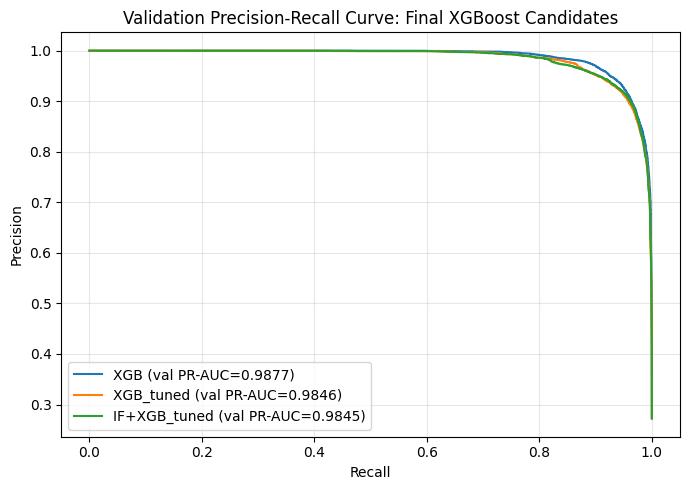

Held-out test evaluation is deferred to Notebook 03.


In [27]:
# Select the top final XGBoost candidates for visual comparison
top_visual_models = (
    xgb_final_validation_table.assign(family="final_xgb_candidate")
    .sort_values(["val_pr_auc", "val_roc_auc", "val_f1"], ascending=False)
    .head(3)
    .reset_index(drop=True)
)

# Create the validation precision-recall plot
plt.figure(figsize=(7, 5))

# Plot precision-recall curves for the top validation-ranked candidates
for _, row in top_visual_models.iterrows():
    # Retrieve stored validation probabilities for the current candidate
    result = xgb_candidate_results[row["model"]]
    # Calculate the precision-recall curve on the validation split
    precision, recall, _ = precision_recall_curve(y_val, result["val_prob"])
    # Add the candidate curve to the plot
    plt.plot(recall, precision, label=f"{row['model']} (val PR-AUC={row['val_pr_auc']:.4f})")

# Label and format the precision-recall plot
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curve: Final XGBoost Candidates")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Held-out test evaluation is deferred to Notebook 03.")

In [28]:
print("NOTEBOOK 02 SUMMARY")
print(f"  Rows loaded (combined)           : {len(df):>10,}")
print(f"  Train split                      : {len(train_df):>10,}")
print(f"  Validation split                 : {len(val_df):>10,}")
print(f"  Test split                       : {len(test_df):>10,}")
print(f"  Base feature count               : {len(feature_names_out):>10}")
print(f"  Benign-only IF training rows     : {X_train_benign.shape[0]:>10,}")
print(f"  Benign-only OCSVM training rows  : {OCSVM_TRAIN_ROWS_USED:>10,}")
print(f"  Selected best anomaly model      : {best_anomaly_model_name}")
print(f"  Final chosen model               : {final_selected_model_name}")
print(f"  Final chosen threshold           : {final_selected_result['threshold']:.6f}")
print("  Test-set use in Notebook 02      : final selected model export only")
print()
print("Split summary")
display(split_summary_df)
print("Registered-domain overlap audit")
display(split_overlap_audit_df)
print("Threshold summary - validation tuned")
display(threshold_summary_df)
print("XGBoost tuning results - validation only")
display(xgb_tuning_results)
print("Final compact comparison - validation only")
display(xgb_final_validation_table)
print("Source-bias audit (collection-failure features)")
display(source_bias_feature_audit_df)
display(source_bias_ablation_df)
print("Saved artefacts:")
for name, path in saved_paths.items():
    print(f"  {name:30s} -> {path}")

NOTEBOOK 02 SUMMARY
  Rows loaded (combined)           :    505,539
  Train split                      :    336,380
  Validation split                 :     76,939
  Test split                       :     92,220
  Base feature count               :         21
  Benign-only IF training rows     :    233,719
  Benign-only OCSVM training rows  :     10,000
  Selected best anomaly model      : IF
  Final chosen model               : XGB
  Final chosen threshold           : 0.517574
  Test-set use in Notebook 02      : final selected model export only

Split summary


,split,row_count,benign_rows,phishing_rows,distinct_registered_domains,distinct_domains
0,train,336380,233719,102661,109456,336380
1,val,76939,55964,20975,23455,76939
2,test,92220,52357,39863,23455,92220


Registered-domain overlap audit


,left_split,right_split,key,overlap_count
0,train,val,registered_domain,0
1,train,test,registered_domain,0
2,val,test,registered_domain,0


Threshold summary - validation tuned


...

,model,threshold,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc
0,XGB,0.517574,0.9367,0.9431,0.9399,0.9948,0.9877
1,XGB_tuned,0.523347,0.9222,0.9430,0.9325,0.9935,0.9846
2,IF+XGB_tuned,0.501644,0.9193,0.9486,0.9337,0.9935,0.9845


Source-bias audit (collection-failure features)


,source_dataset,feature,missing_count,missing_rate,non_null_rows,mean_when_present,train_non_null_rows,train_missing_count,train_missing_rate,train_unique_present_values,train_constant_when_present,used_in_final_model_schema
0,benign_umbrella,a_record_count,0,0.000000,342040,1.025898,336380,0,0.000000,45,False,1
1,phishing,a_record_count,0,0.000000,163499,1.055156,336380,0,0.000000,45,False,1
2,benign_umbrella,aaaa_record_count,0,0.000000,342040,0.316024,336380,0,0.000000,26,False,1
3,phishing,aaaa_record_count,0,0.000000,163499,0.532034,336380,0,0.000000,26,False,1
4,benign_umbrella,cert_days_until_expiry,62791,0.183578,279249,1620.030346,272769,63611,0.189105,3212,False,1
5,phishing,cert_days_until_expiry,33066,0.202240,130433,883.243374,272769,63611,0.189105,3212,False,1
6,benign_umbrella,cert_expired,62791,0.183578,279249,0.003857,272769,63611,0.189105,2,False,1
7,phishing,cert_expired,33066,0.202240,130433,0.002499,272769,63611,0.189105,2,False,1
8,benign_umbrella,cert_present,0,0.000000,342040,0.816431,336380,0,0.000000,2,False,1
9,phishing,cert_present,0,0.000000,163499,0.797760,336380,0,0.000000,2,False,1


,model,threshold,val_precision,val_recall,val_f1,val_roc_auc,val_pr_auc,feature_count,dropped_features,best_params,delta_val_precision,delta_val_recall,delta_val_f1,delta_val_roc_auc,delta_val_pr_auc
0,XGB_tuned_full_candidate_schema,0.555107,0.9298,0.9306,0.9302,0.9933,0.9841,25,,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.0...",0.0000,0.0000,0.0000,0.0000,0.0000
1,XGB_tuned_reduced_schema,0.523347,0.9222,0.9430,0.9325,0.9935,0.9846,21,dns_lookup_failed; tls_handshake_success; tls_...,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",-0.0076,0.0124,0.0023,0.0002,0.0005


Saved artefacts:
  preprocessor                   -> /datasets/models/preprocessor.joblib
  xgboost_baseline               -> /datasets/models/xgboost_baseline.joblib
  xgboost_tuned                  -> /datasets/models/xgboost_tuned.joblib
  feature_names                  -> /datasets/models/feature_names.json
  model_feature_schema           -> /datasets/models/model_feature_schema.json
  model_comparison_summary       -> /datasets/evaluation/notebook2_model_comparison_summary.json
  split_manifest                 -> /datasets/audit/notebook2_split_manifest.csv
  split_summary                  -> /datasets/evaluation/notebook2_split_summary.csv
  split_overlap_audit            -> /datasets/evaluation/notebook2_split_registered_domain_overlap.csv
  threshold_summary              -> /datasets/evaluation/notebook2_threshold_summary.csv
  source_bias_feature_audit      -> /datasets/evaluation/notebook2_source_bias_feature_audit.csv
  source_bias_ablation           -> /datasets/evaluation